# 🤖 Training a Machine Learning Model with Non-Differentiable Loss Functions Using Sub-gradient Descent

## 📂  Banknote Authentication Dataset Description

The dataset contains data extracted from images of both **genuine** and **forged** banknote-like specimens. Key characteristics:

- 📷 Images were captured using an **industrial camera** typically used for print inspection.
- 🖼️ Each image has a resolution of **400 × 400 pixels**, scanned at approximately **660 dpi**.
- 🎛️ The **Wavelet Transform** technique was applied to extract meaningful features from the gray-scale images.
- 📊 The dataset includes statistical measures derived from these wavelet-transformed images.

These features are used to distinguish between genuine and counterfeit banknotes for training a classification model.


## 🧾 Attribute Information

Each record in the dataset consists of 5 attributes:

| 🔢 Feature | 📄 Description                                      | 📈 Type       |
|------------|------------------------------------------------------|---------------|
| `variance` | Variance of Wavelet Transformed image                | Continuous    |
| `skewness` | Skewness of Wavelet Transformed image                | Continuous    |
| `curtosis` | Curtosis (peakedness) of Wavelet Transformed image   | Continuous    |
| `entropy`  | Entropy of the image                                 | Continuous    |
| `class`    | Classification label (0 = Forged, 1 = Genuine)  eger | Integer (0/1) |
eger)

 ### 📊  Prepare The Dataset:

In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv("data_banknote_authentication.csv")
df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
# Display the first few rows
print(df.head())  


   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [2]:
# Get information about data types and non-null counts
print(df.info())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


In [3]:
# Get summary statistics
print(df.describe())  

          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [4]:
 # Check for missing values
print(df.isnull().sum()) 

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


🧠 we conclude that data do not have null value.

In [5]:
#  Check for Duplicates
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
df=df.drop_duplicates(keep='first')
df # Remove duplicate rows

Duplicate rows: 24


,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


🧠 we conclude we have 24 row duplicated so we remove it.

In [33]:
# Check data types
print(df.dtypes)

variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object


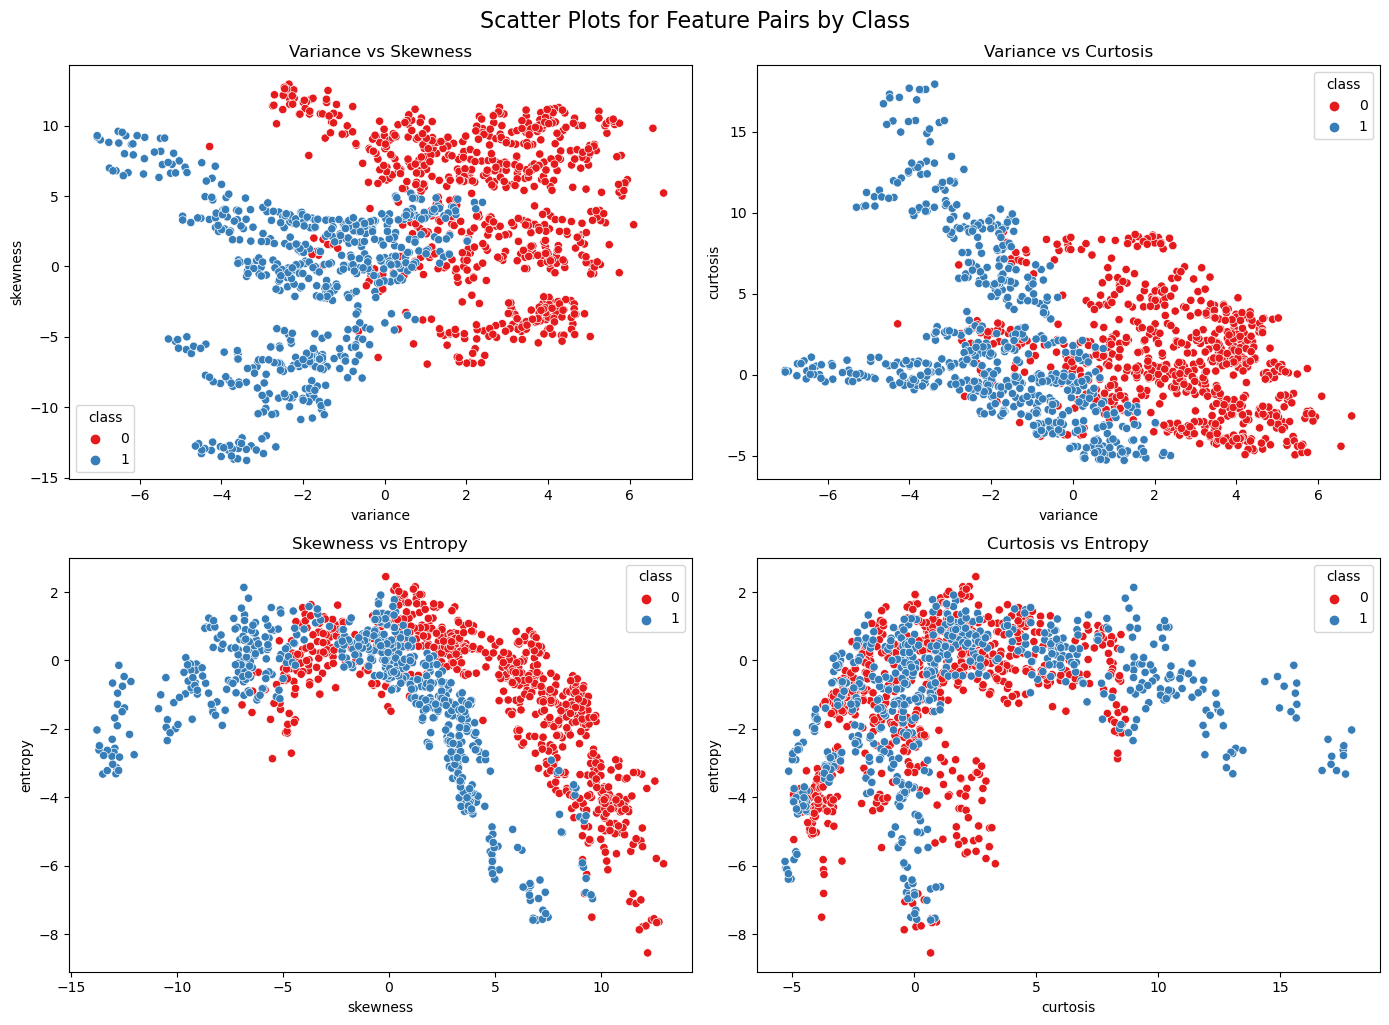

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='variance', y='skewness', hue='class', palette='Set1')
plt.title('Variance vs Skewness')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='variance', y='curtosis', hue='class', palette='Set1')
plt.title('Variance vs Curtosis')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='skewness', y='entropy', hue='class', palette='Set1')
plt.title('Skewness vs Entropy')

plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='curtosis', y='entropy', hue='class', palette='Set1')
plt.title('Curtosis vs Entropy')

plt.tight_layout()
plt.suptitle('Scatter Plots for Feature Pairs by Class', y=1.02, fontsize=16)
plt.show()


🧠 we conclude from chart the data non sepripl so kernel svm more use in these cases than soft svm.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
#  df is already loaded and cleaned
X = df.drop(columns='class').values
y = df['class'].values

# Convert class labels from {0, 1} to {-1, 1}
y = np.where(y == 0, -1, 1)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [25]:
def rbf_kernel(X1, X2, gamma):
    if X1.ndim == 1:
        X1 = X1.reshape(1, -1)
    if X2.ndim == 1:
        X2 = X2.reshape(1, -1)
    sq_dists = np.sum(X1**2, axis=1)[:, np.newaxis] + np.sum(X2**2, axis=1) - 2 * X1 @ X2.T
    return np.exp(-gamma * sq_dists)


-->This rbf_kernel function calculates the Radial Basis Function (RBF) kernel, also known as the Gaussian kernel, which is commonly used in kernelized SVMs.

🔍 Purpose:

-->To compute a similarity measure between each pair of points in two datasets X1 and X2. The result is a kernel matrix 

-->This captures how close two points are in space. The closer they are, the closer the kernel value is to 1; the farther, the closer to 0.


-->kernel: the kernel function (default: rbf_kernel)

-->C: regularization parameter

-->lr: learning rate

-->max_iter: number of training iterations

-->gamma: kernel coefficient (used in RBF)

**🔍fit_gradient**

-->Stores the training data

-->Computes the kernel matrix 𝐾

-->Initializes dual variables alpha to zero

-->For each iteration:

        Computes the margin, Calculates the gradient: (1−margin)

         Updates alpha using gradient descent

🧠 The idea: maximize the dual SVM objective by minimizing hinge loss in dual space.

**🔍fit_subgradient**

-->Similar to above, but uses coordinate-wise updates:

Loops over each sample i

Checks the margin for sample i

Updates only alpha[i] if the margin is less than 1

**🔍project**

Computes the kernel between new data and training data

**🔍predict**

Applies the sign function to get class label predictions

In [29]:
class KernelSVM:
    def __init__(self, kernel=rbf_kernel, C=1.0, lr=0.01, max_iter=100, gamma=0.5):
        self.kernel = kernel
        self.C = C
        self.lr = lr
        self.max_iter = max_iter
        self.gamma = gamma
        self.loss_type = 'squared_hinge'  # or 'hinge'

        self.gd_losses, self.gd_accuracies, self.gd_val_accuracies = [], [], []
        self.subgd_losses, self.subgd_accuracies, self.subgd_val_accuracies = [], [], []

    def set_loss(self, loss_type):
        if loss_type not in ['squared_hinge', 'hinge']:
            raise ValueError("Loss must be 'squared_hinge' or 'hinge'")
        self.loss_type = loss_type

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def project(self, X):
        K = self.kernel(X, self.X_train, self.gamma)
        return np.dot(K, self.alpha * self.y_train)

    def predict(self, X):
        return np.sign(self.project(X))
    # 🔁 Loss Function
    def compute_loss(self, K, y):
        margin = 1 - y * (K @ (self.alpha * y))
        if self.loss_type == 'squared_hinge':
            losses = np.maximum(0, margin) ** 2
        else:  # hinge loss
            losses = np.maximum(0, margin)
        return 0.5 * (self.alpha @ K @ (self.alpha * y**2)) + self.C * np.sum(losses)
   #📈 Gradient Descent Training
    def fit_gradient(self, X, y, X_test=None, y_test=None):
        self.X_train = X
        self.y_train = y
        n_samples = X.shape[0]
        K = self.kernel(X, X, self.gamma)
        self.alpha = np.zeros(n_samples)

        self.gd_losses.clear()
        self.gd_accuracies.clear()
        self.gd_val_accuracies.clear()

        for it in range(self.max_iter):
            margin = 1 - y * (K @ (self.alpha * y))

            if self.loss_type == 'squared_hinge':
                grad = -2 * self.C * margin * (margin > 0) * y
            else:  # hinge
                grad = -self.C * y * (margin > 0)

            self.alpha -= self.lr * (K @ (self.alpha * y) * y + grad)
            self.alpha = np.clip(self.alpha, 0, self.C)

            loss = self.compute_loss(K, y)
            train_acc = self.accuracy(X, y)
            val_acc = self.accuracy(X_test, y_test) if X_test is not None else None

            self.gd_losses.append(loss)
            self.gd_accuracies.append(train_acc)
            self.gd_val_accuracies.append(val_acc)

            print(f"[GD-{self.loss_type}] Epoch {it+1}: Loss={loss:.4f}, Train Acc={train_acc:.4f}")
    # 🔻 Subgradient Descent Training
    def fit_subgradient(self, X, y, X_test=None, y_test=None):
        self.X_train = X
        self.y_train = y
        n_samples = X.shape[0]
        K = self.kernel(X, X, self.gamma)
        self.alpha = np.zeros(n_samples)

        self.subgd_losses.clear()
        self.subgd_accuracies.clear()
        self.subgd_val_accuracies.clear()

        for it in range(self.max_iter):
            for i in range(n_samples):
                margin = y[i] * np.sum(self.alpha * y * K[:, i])
                if self.loss_type == 'squared_hinge':
                    grad = -2 * self.C * (1 - margin) * y[i] if margin < 1 else 0
                else:
                    grad = -self.C * y[i] if margin < 1 else 0

                self.alpha[i] -= self.lr * (np.sum(K[i] * self.alpha * y**2) + grad)
                self.alpha[i] = np.clip(self.alpha[i], 0, self.C)

            loss = self.compute_loss(K, y)
            train_acc = self.accuracy(X, y)
            val_acc = self.accuracy(X_test, y_test) if X_test is not None else None

            self.subgd_losses.append(loss)
            self.subgd_accuracies.append(train_acc)
            self.subgd_val_accuracies.append(val_acc)

            print(f"[SubGD-{self.loss_type}] Epoch {it+1}: Loss={loss:.4f}, Train Acc={train_acc:.4f}")
    # 📊  Plotting Training History
    def plot_metrics(self, method='gd'):
        if method == 'gd':
            losses = self.gd_losses
            acc_train = self.gd_accuracies
            acc_val = self.gd_val_accuracies
            title = f'GD ({self.loss_type})'
        else:
            losses = self.subgd_losses
            acc_train = self.subgd_accuracies
            acc_val = self.subgd_val_accuracies
            title = f'SubGD ({self.loss_type})'

        epochs = range(1, len(losses) + 1)
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, losses, label='Loss', color='blue')
        plt.title(f'{title}: Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs, acc_train, label='Train Accuracy', color='green')
        if acc_val and acc_val[0] is not None:
            plt.plot(epochs, acc_val, label='Validation Accuracy', color='red')
        plt.title(f'{title}: Accuracy Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()


In [30]:
print(hasattr(KernelSVM, 'fit_gradient'))  # should print True


True


[GD-squared_hinge] Epoch 1: Loss=2381.6342, Train Acc=0.4518
[GD-squared_hinge] Epoch 2: Loss=997.2837, Train Acc=0.4518
[GD-squared_hinge] Epoch 3: Loss=2189.2293, Train Acc=0.4518
[GD-squared_hinge] Epoch 4: Loss=1001.6374, Train Acc=0.4518
[GD-squared_hinge] Epoch 5: Loss=2191.9540, Train Acc=0.4518
[GD-squared_hinge] Epoch 6: Loss=1001.6810, Train Acc=0.4518
[GD-squared_hinge] Epoch 7: Loss=2189.9174, Train Acc=0.4518
[GD-squared_hinge] Epoch 8: Loss=1000.0017, Train Acc=0.4518
[GD-squared_hinge] Epoch 9: Loss=2180.1033, Train Acc=0.4518
[GD-squared_hinge] Epoch 10: Loss=998.7619, Train Acc=0.4518
[GD-squared_hinge] Epoch 11: Loss=2170.1606, Train Acc=0.4518
[GD-squared_hinge] Epoch 12: Loss=997.8863, Train Acc=0.4518
[GD-squared_hinge] Epoch 13: Loss=2161.0099, Train Acc=0.4518
[GD-squared_hinge] Epoch 14: Loss=997.4377, Train Acc=0.4518
[GD-squared_hinge] Epoch 15: Loss=2153.2053, Train Acc=0.4518
[GD-squared_hinge] Epoch 16: Loss=996.9072, Train Acc=0.4518
[GD-squared_hinge] Epo

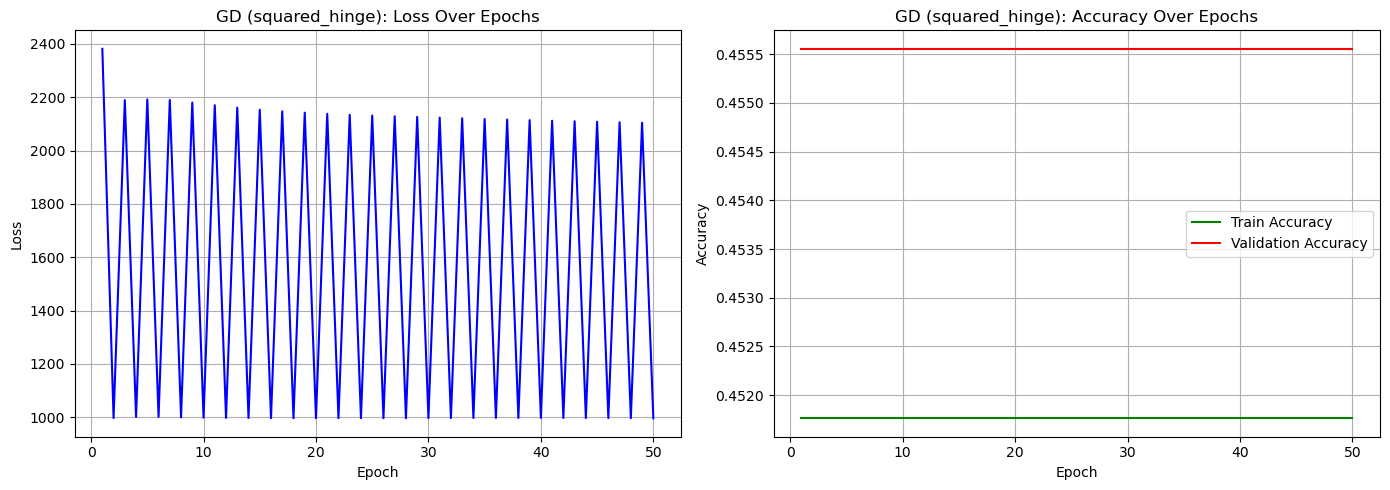

[SubGD-hinge] Epoch 1: Loss=920.9708, Train Acc=0.4518
[SubGD-hinge] Epoch 2: Loss=882.0240, Train Acc=0.4518
[SubGD-hinge] Epoch 3: Loss=869.0805, Train Acc=0.4518
[SubGD-hinge] Epoch 4: Loss=865.1502, Train Acc=0.4518
[SubGD-hinge] Epoch 5: Loss=863.1145, Train Acc=0.4518
[SubGD-hinge] Epoch 6: Loss=862.0566, Train Acc=0.4518
[SubGD-hinge] Epoch 7: Loss=861.9358, Train Acc=0.4518
[SubGD-hinge] Epoch 8: Loss=861.7647, Train Acc=0.4518
[SubGD-hinge] Epoch 9: Loss=862.1107, Train Acc=0.4518
[SubGD-hinge] Epoch 10: Loss=862.1636, Train Acc=0.4518
[SubGD-hinge] Epoch 11: Loss=862.0356, Train Acc=0.4518
[SubGD-hinge] Epoch 12: Loss=862.8859, Train Acc=0.4518
[SubGD-hinge] Epoch 13: Loss=863.8321, Train Acc=0.4518
[SubGD-hinge] Epoch 14: Loss=864.6707, Train Acc=0.4518
[SubGD-hinge] Epoch 15: Loss=864.8503, Train Acc=0.4518
[SubGD-hinge] Epoch 16: Loss=864.8986, Train Acc=0.4518
[SubGD-hinge] Epoch 17: Loss=865.2290, Train Acc=0.4518
[SubGD-hinge] Epoch 18: Loss=866.5702, Train Acc=0.4518
[

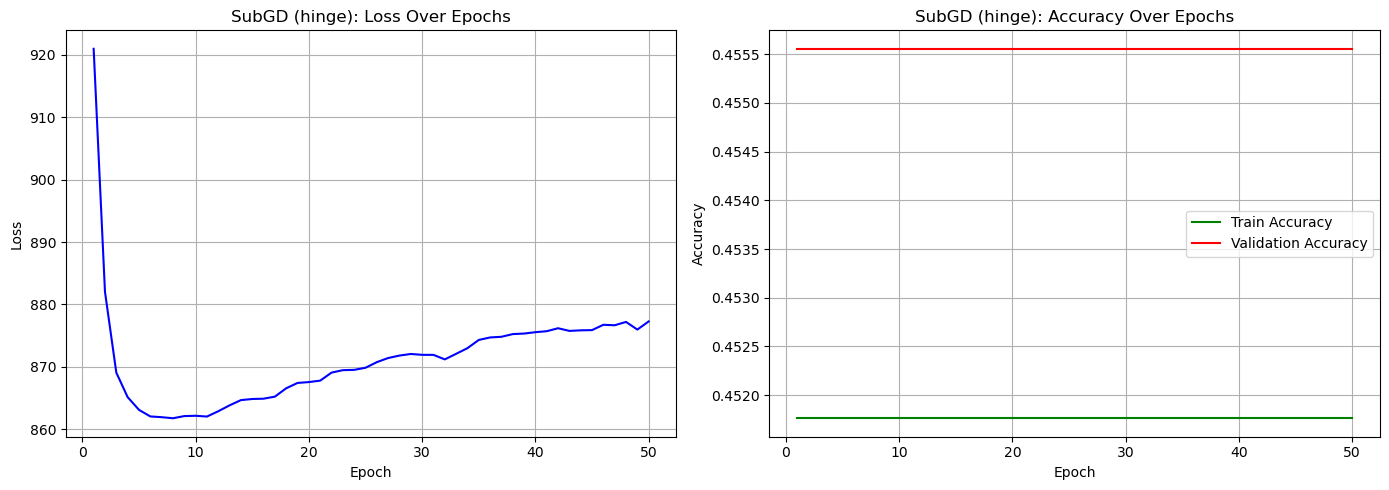

In [33]:
svm = KernelSVM(C=1.0, lr=0.01, max_iter=50, gamma=0.5)

# Use squared hinge loss with gradient descent
svm.set_loss('squared_hinge')
svm.fit_gradient(X_train, y_train, X_test, y_test)
svm.plot_metrics(method='gd')

# Use hinge loss with subgradient descent
svm.set_loss('hinge')
svm.fit_subgradient(X_train, y_train, X_test, y_test)
svm.plot_metrics(method='subgd')


In [11]:
# Plot results
model.plot_metrics(method="gd")

AttributeError: 'KernelSVM' object has no attribute 'plot_metrics'

Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000


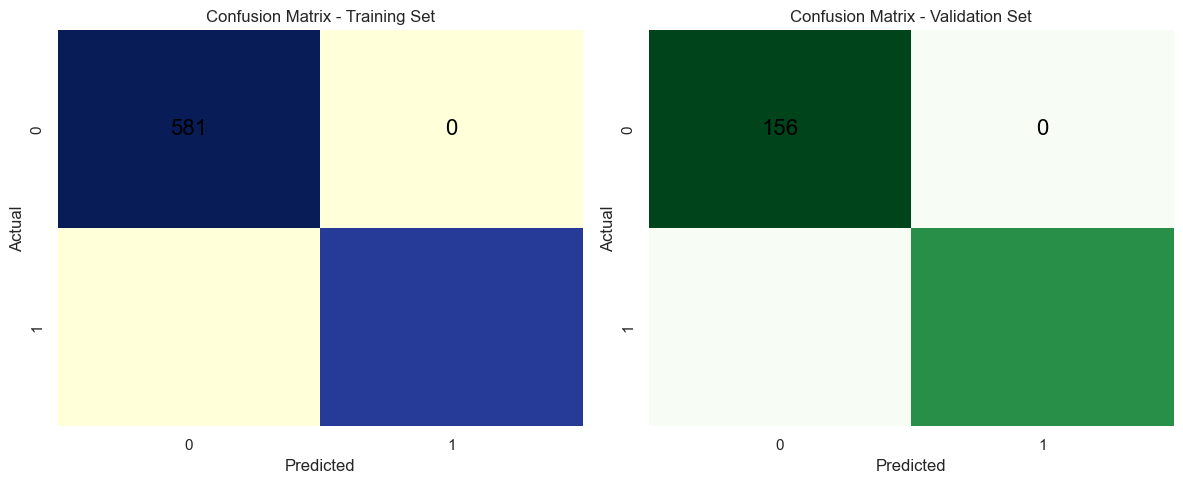

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Predict on training and validation ---
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_test)

# --- Accuracy ---
acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_test, y_pred_val)

print(f"Final Training Accuracy: {acc_train:.4f}")
print(f"Final Validation Accuracy: {acc_val:.4f}")

# --- Confusion Matrices ---
cm_train = confusion_matrix(y_train, y_pred_train)
cm_val = confusion_matrix(y_test, y_pred_val)

# --- Plot Confusion Matrices ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt="d", cmap="YlGnBu", ax=axs[0],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[0].set_title("Confusion Matrix - Training Set")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", ax=axs[1],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[1].set_title("Confusion Matrix - Validation Set")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

| Condition               | Interpretation                              |
| ----------------------- | ------------------------------------------- |
| Training acc ≈ Test acc | ✅ Model generalizes well                    |
| Training acc ≫ Test acc | ❌ Model is overfitting                      |
| Both are low            | ❌ Model is underfitting or poorly optimized |


In [41]:
# Train the model
model_Two = KernelSVM(max_iter=100)
model_Two.fit_subgradient(X_train, y_train, X_test, y_test)

[SubGD] Epoch 1: Loss = -2.3190, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 2: Loss = -2.6888, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 3: Loss = -2.8423, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 4: Loss = -2.9179, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 5: Loss = -2.9630, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 6: Loss = -2.9951, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 7: Loss = -3.0196, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 8: Loss = -3.0388, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 9: Loss = -3.0549, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 10: Loss = -3.0690, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 11: Loss = -3.0818, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 12: Loss = -3.0933, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 13: Loss = -3.1039, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 14: Loss = -3.1135, Train Acc = 0.5395, Val Acc = 0.5778
[SubGD] Epoch 1

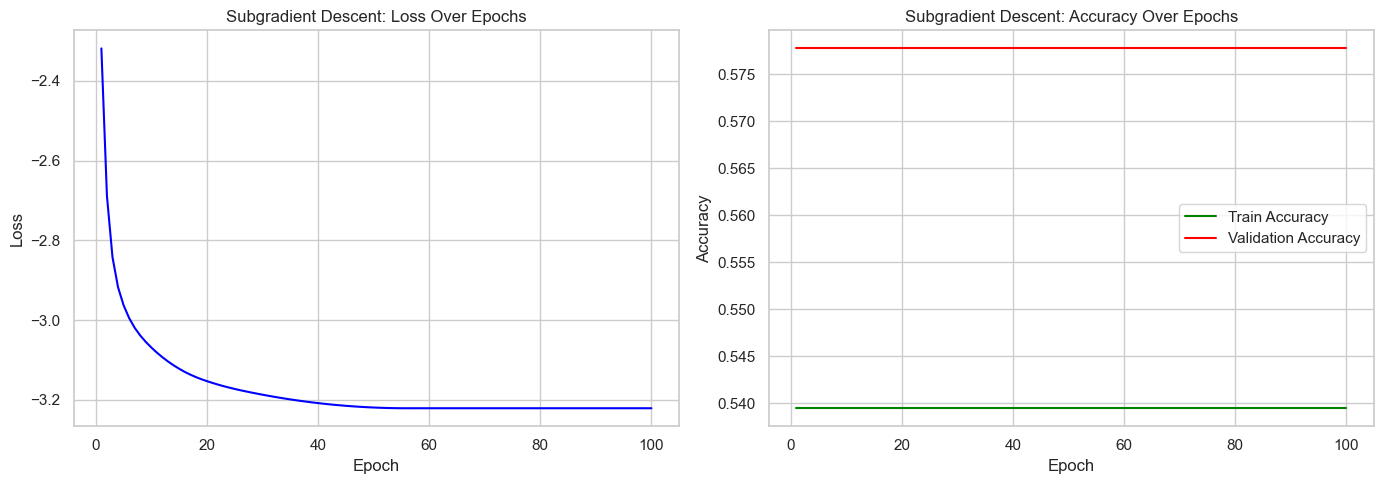

In [46]:
# Plot results
model_Two.plot_metrics(method="sub")

Final Training Accuracy: 0.5395
Final Validation Accuracy: 0.5778


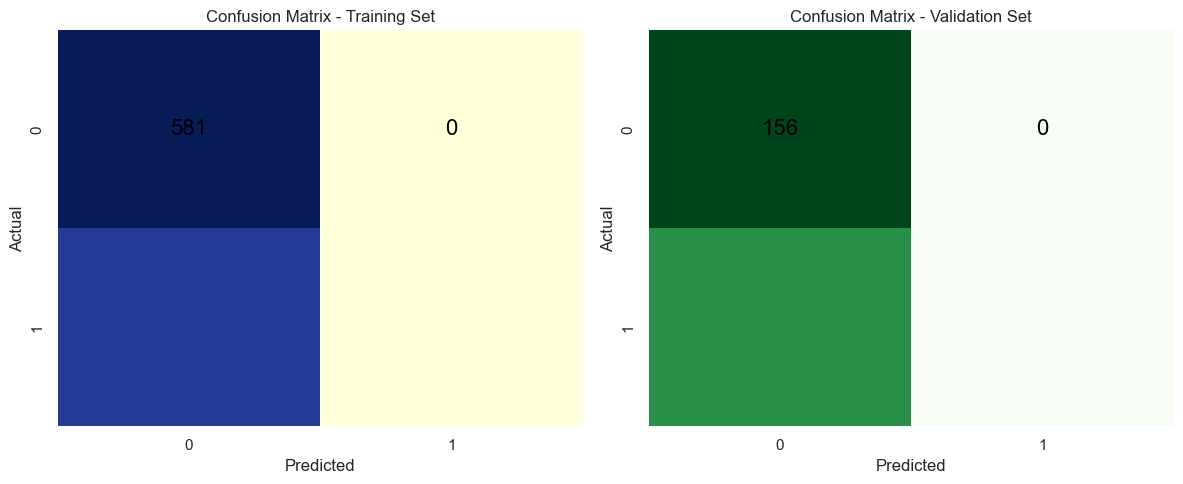

In [96]:
# --- Predict on training and validation ---
y_pred_train = model_Two.predict(X_train)
y_pred_val = model_Two.predict(X_test)

# --- Accuracy ---
acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_test, y_pred_val)

print(f"Final Training Accuracy: {acc_train:.4f}")
print(f"Final Validation Accuracy: {acc_val:.4f}")

# --- Confusion Matrices ---
cm_train = confusion_matrix(y_train, y_pred_train)
cm_val = confusion_matrix(y_test, y_pred_val)

# --- Plot Confusion Matrices ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt="d", cmap="YlGnBu", ax=axs[0],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[0].set_title("Confusion Matrix - Training Set")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", ax=axs[1],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[1].set_title("Confusion Matrix - Validation Set")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [52]:
class KernelSVM:
    def __init__(self, C=1.0, lr=0.01, max_iter=1000, gamma=1.0):
        self.C = C
        self.lr = lr
        self.max_iter = max_iter
        self.gamma = gamma
        self.alpha = None
        self.X_train = None
        self.y_train = None

    def rbf_kernel(self, X1, X2):
        sq_dists = np.sum((X1[:, np.newaxis] - X2) ** 2, axis=2)
        return np.exp(-self.gamma * sq_dists)

    def fit_subgradient(self, X, y):
        self.X_train = X
        self.y_train = y
        n_samples = X.shape[0]
        K = self.rbf_kernel(X, X)
        self.alpha = np.zeros(n_samples)

        for it in range(1, self.max_iter + 1):
            lr_t = self.lr / np.sqrt(it)  # Decaying learning rate

            for i in range(n_samples):
                condition = y[i] * np.dot(self.alpha * y, K[:, i])
                if condition < 1:
                    self.alpha[i] += lr_t * (1 - self.C * condition)

            # Optional: print loss occasionally
            if it % 100 == 0:
                margin = y * np.dot(self.alpha * y, K)
                hinge_loss = np.maximum(0, 1 - margin)
                loss = 0.5 * np.dot(self.alpha, np.dot(K, self.alpha)) + self.C * np.sum(hinge_loss)
                print(f"Iteration {it}: Subgradient Loss = {loss:.4f}")

    def predict(self, X):
        K = self.rbf_kernel(X, self.X_train)
        decision = np.dot(K, self.alpha * self.y_train)
        return np.sign(decision)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)


In [54]:
# Retrain with improved subgradient method
model_subgrad = KernelSVM(C=1.0, lr=0.1, max_iter=2000)  # Increased iterations and learning rate
model_subgrad.fit_subgradient(X_train, y_train)

# Train/Test accuracy
train_preds_subgrad = model_subgrad.predict( X_train)
test_preds_subgrad = model_subgrad.predict( X_test)

acc_train_subgrad = model_subgrad.accuracy(X_train, y_train)
acc_test_subgrad = model_subgrad.accuracy(X_test, y_test)


print("\nImproved Subgradient Method:")
print("Train Accuracy:", acc_train_subgrad)
print("Test Accuracy :", acc_test_subgrad)


Iteration 100: Subgradient Loss = 113.7354
Iteration 200: Subgradient Loss = 131.2249
Iteration 300: Subgradient Loss = 142.6116
Iteration 400: Subgradient Loss = 151.0948
Iteration 500: Subgradient Loss = 157.8165
Iteration 600: Subgradient Loss = 163.3879
Iteration 700: Subgradient Loss = 168.1328
Iteration 800: Subgradient Loss = 172.2448
Iteration 900: Subgradient Loss = 175.8589
Iteration 1000: Subgradient Loss = 179.0719
Iteration 1100: Subgradient Loss = 181.9532
Iteration 1200: Subgradient Loss = 184.5544
Iteration 1300: Subgradient Loss = 186.9165
Iteration 1400: Subgradient Loss = 189.0727
Iteration 1500: Subgradient Loss = 191.0498
Iteration 1600: Subgradient Loss = 192.8696
Iteration 1700: Subgradient Loss = 194.5507
Iteration 1800: Subgradient Loss = 196.1084
Iteration 1900: Subgradient Loss = 197.5560
Iteration 2000: Subgradient Loss = 198.9048

Improved Subgradient Method:
Train Accuracy: 1.0
Test Accuracy : 1.0


In [61]:
new_data = np.array([4.54590, 8.1674, -2.4586, -1.46210]).reshape(1, -1)

# Prediction
prediction_grad = model.predict(new_data)
print("Predicted class by Gradient model:", prediction_grad[0])
prediction_subgrad = model_Two.predict(new_data)
print("Predicted class by Subgradient model:", prediction_subgrad[0])
rediction_subgrad = model_subgrad.predict(new_data1)
print("Predicted class by Subgradient model:", prediction_subgrad[0])


Predicted class by Gradient model: -1.0
Predicted class by Subgradient model: -1.0
Predicted class by Subgradient model: -1.0


In [60]:
new_data1 = np.array([-2.54190,-0.65804,2.6842,1.19520]).reshape(1, -1) 
# Prediction
prediction_grad = model.predict(new_data1)
print("Predicted class by Gradient model:", prediction_grad[0])
prediction_subgrad = model_Two.predict(new_data1)
print("Predicted class by Subgradient model:", prediction_subgrad[0])
prediction_subgrad = model_subgrad.predict(new_data1)
print("Predicted class by Subgradient model:", prediction_subgrad[0])

Predicted class by Gradient model: 1.0
Predicted class by Subgradient model: -1.0
Predicted class by Subgradient model: 1.0


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class LinearSVM:
    def __init__(self, C=1.0, lr=0.01, max_iter=100):
        self.C = C
        self.lr = lr
        self.max_iter = max_iter
        self.history = {'loss': [], 'train_acc': [], 'val_acc': []}

    def compute_loss(self, X, y):
        margins = np.maximum(0, 1 - y * (X @ self.w + self.b))
        return 0.5 * np.dot(self.w, self.w) + self.C * np.sum(margins)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def fit_gradient(self, X, y, X_test=None, y_test=None):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for it in range(self.max_iter):
            margin = y * (X @ self.w + self.b)
            indicator = margin < 1
            dw = self.w - self.C * (X[indicator].T @ y[indicator])
            db = -self.C * np.sum(y[indicator])

            self.w -= self.lr * dw
            self.b -= self.lr * db

            loss = self.compute_loss(X, y)
            train_acc = self.accuracy(X, y)
            val_acc = self.accuracy(X_test, y_test) if X_test is not None else None

            self.history['loss'].append(loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            print(f"Epoch {it+1}: Loss = {loss:.4f}, Training Accuracy = {train_acc:.4f}", end="")
            if val_acc is not None:
                print(f", Validation Accuraccy = {val_acc:.4f}")
            else:
                print()

    def fit_subgradient(self, X, y, X_test=None, y_test=None):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for t in range(1, self.max_iter + 1):
            lr_t = self.lr / np.sqrt(t)
            for i in range(n_samples):
                margin = y[i] * (np.dot(self.w, X[i]) + self.b)
                if margin < 1:
                    self.w = self.w - lr_t * (self.w - self.C * y[i] * X[i])
                    self.b = self.b + lr_t * self.C * y[i]
                else:
                    self.w = self.w - lr_t * self.w

            loss = self.compute_loss(X, y)
            train_acc = self.accuracy(X, y)
            val_acc = self.accuracy(X_test, y_test) if X_test is not None else None

            self.history['loss'].append(loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            print(f"Epoch {t}: Loss = {loss:.4f}, Training Accuracy = {train_acc:.4f}", end="")
            if val_acc is not None:
                print(f", Validation Accuracy = {val_acc:.4f}")
            else:
                print()

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

    def plot_metrics(self):
        epochs = range(1, self.max_iter + 1)
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['loss'], label='Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss over Epochs")
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['train_acc'], label='Train Acc', color='green')
        if self.history['val_acc'][0] is not None:
            plt.plot(epochs, self.history['val_acc'], label='Val Acc', color='red')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()


In [63]:
# Train Gradient Descent SVM
svm_grad = LinearSVM(C=1.0, lr=0.01, max_iter=100)
svm_grad.fit_gradient(X_train, y_train,X_test, y_test)

Epoch 1: Loss = 843.5458, Training Accuracy = 0.8477, Validation Accuraccy = 0.8778
Epoch 2: Loss = 442.2491, Training Accuracy = 0.8849, Validation Accuraccy = 0.9111
Epoch 3: Loss = 230.3870, Training Accuracy = 0.9350, Validation Accuraccy = 0.9407
Epoch 4: Loss = 139.9643, Training Accuracy = 0.9638, Validation Accuraccy = 0.9667
Epoch 5: Loss = 100.7216, Training Accuracy = 0.9749, Validation Accuraccy = 0.9741
Epoch 6: Loss = 84.5087, Training Accuracy = 0.9805, Validation Accuraccy = 0.9815
Epoch 7: Loss = 75.5782, Training Accuracy = 0.9824, Validation Accuraccy = 0.9852
Epoch 8: Loss = 68.1687, Training Accuracy = 0.9861, Validation Accuraccy = 0.9852
Epoch 9: Loss = 62.5750, Training Accuracy = 0.9889, Validation Accuraccy = 0.9889
Epoch 10: Loss = 58.0092, Training Accuracy = 0.9898, Validation Accuraccy = 0.9889
Epoch 11: Loss = 54.7026, Training Accuracy = 0.9898, Validation Accuraccy = 0.9889
Epoch 12: Loss = 52.8476, Training Accuracy = 0.9898, Validation Accuraccy = 0.9

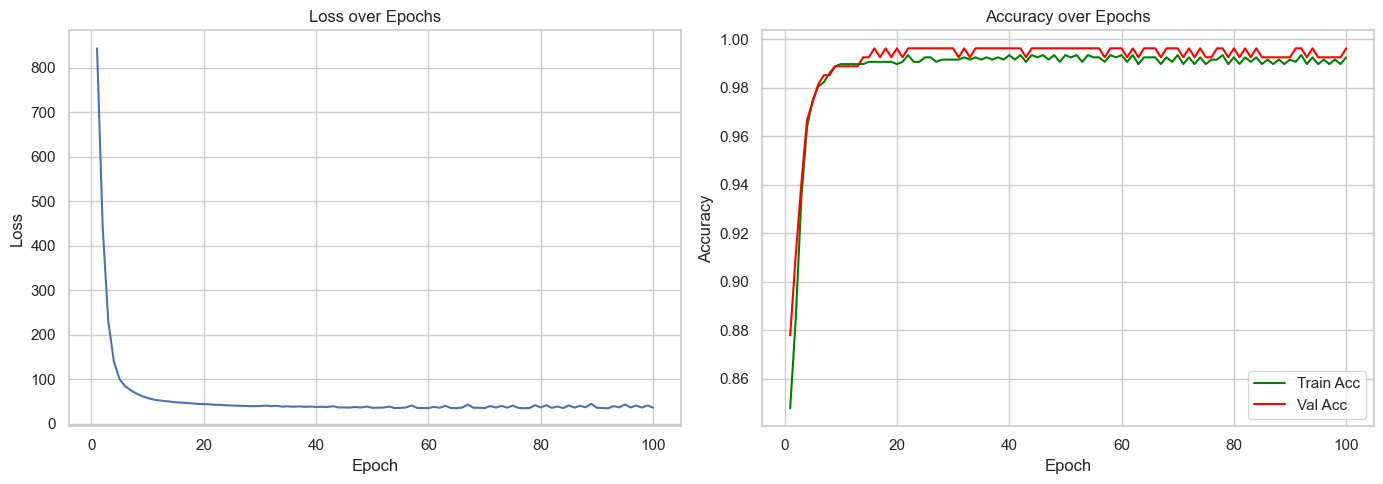

In [64]:
# Plot results
svm_grad.plot_metrics()

Final Training Accuracy: 0.8821
Final Validation Accuracy: 0.8963


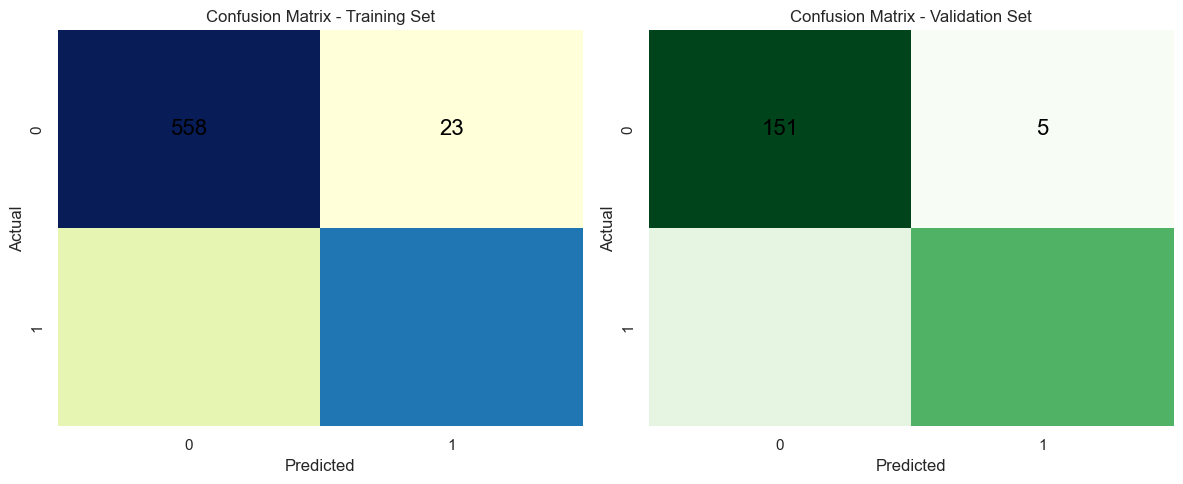

In [95]:
# --- Predict on training and validation ---
y_pred_train = svm_grad.predict(X_train)
y_pred_val = svm_grad.predict(X_test)

# --- Accuracy ---
acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_test, y_pred_val)

print(f"Final Training Accuracy: {acc_train:.4f}")
print(f"Final Validation Accuracy: {acc_val:.4f}")

# --- Confusion Matrices ---
cm_train = confusion_matrix(y_train, y_pred_train)
cm_val = confusion_matrix(y_test, y_pred_val)

# --- Plot Confusion Matrices ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt="d", cmap="YlGnBu", ax=axs[0],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[0].set_title("Confusion Matrix - Training Set")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", ax=axs[1],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[1].set_title("Confusion Matrix - Validation Set")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [71]:
# Train Gradient Descent SVM
svm_subgrad = LinearSVM(C=1.0, lr=0.01, max_iter=100)
svm_subgrad.fit_subgradient(X_train, y_train,X_test, y_test)

Epoch 1: Loss = 545.1949, Training Accuracy = 0.8960, Validation Accuracy = 0.9185
Epoch 2: Loss = 543.7339, Training Accuracy = 0.8942, Validation Accuracy = 0.9037
Epoch 3: Loss = 553.7007, Training Accuracy = 0.8988, Validation Accuracy = 0.9148
Epoch 4: Loss = 554.3833, Training Accuracy = 0.8979, Validation Accuracy = 0.9148
Epoch 5: Loss = 557.0996, Training Accuracy = 0.8960, Validation Accuracy = 0.9148
Epoch 6: Loss = 559.5755, Training Accuracy = 0.8960, Validation Accuracy = 0.9148
Epoch 7: Loss = 558.6426, Training Accuracy = 0.8951, Validation Accuracy = 0.9074
Epoch 8: Loss = 555.4702, Training Accuracy = 0.8942, Validation Accuracy = 0.9074
Epoch 9: Loss = 554.4395, Training Accuracy = 0.8904, Validation Accuracy = 0.9000
Epoch 10: Loss = 554.6581, Training Accuracy = 0.8895, Validation Accuracy = 0.9037
Epoch 11: Loss = 553.6706, Training Accuracy = 0.8886, Validation Accuracy = 0.9000
Epoch 12: Loss = 554.9848, Training Accuracy = 0.8886, Validation Accuracy = 0.9074
E

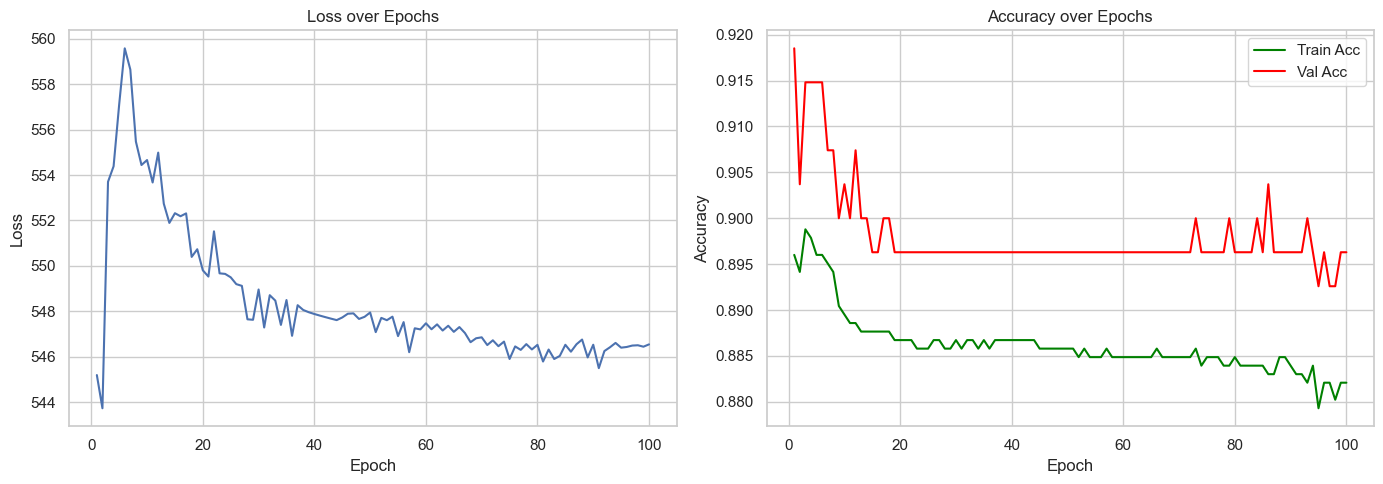

In [72]:
# Plot results
svm_subgrad.plot_metrics()

Final Training Accuracy: 0.8821
Final Validation Accuracy: 0.8963


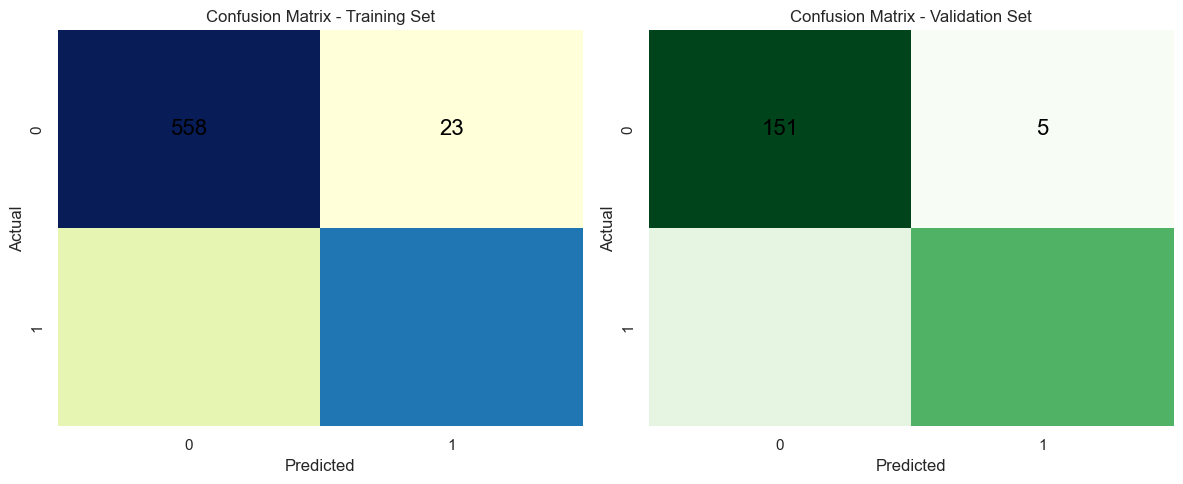

In [98]:
# --- Predict on training and validation ---
y_pred_train = svm_subgrad.predict(X_train)
y_pred_val = svm_subgrad.predict(X_test)

# --- Accuracy ---
acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_test, y_pred_val)

print(f"Final Training Accuracy: {acc_train:.4f}")
print(f"Final Validation Accuracy: {acc_val:.4f}")

# --- Confusion Matrices ---
cm_train = confusion_matrix(y_train, y_pred_train)
cm_val = confusion_matrix(y_test, y_pred_val)

# --- Plot Confusion Matrices ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt="d", cmap="YlGnBu", ax=axs[0],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[0].set_title("Confusion Matrix - Training Set")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", ax=axs[1],annot_kws={"size": 16, "color": "black"},cbar=False)
axs[1].set_title("Confusion Matrix - Validation Set")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [74]:

new_data = np.array([4.54590,8.1674,-2.4586,-1.46210])  

# Predict class labels for new data
predictions = svm_grad.predict( new_data)
rediction_subgrad = svm_subgrad.predict(new_data)
print("Predicted class by Subgradient model:", prediction_subgrad)
print("Predicted class by gradient model:", predictions)

Predicted class by Subgradient model: [-1.]
Predicted class by gradient model: -1.0


In [75]:

new_data = np.array([-3.75030,-13.45860,17.5932,-2.77710]) 

# Predict class labels for new data
predictions = svm_grad.predict( new_data)
rediction_subgrad = svm_subgrad.predict(new_data)
print("Predicted class by Subgradient model:", prediction_subgrad)
print("Predicted class by gradient model:", predictions)

Predicted class by Subgradient model: [-1.]
Predicted class by gradient model: 1.0


## 🔍 Kernel SVM: Gradient Descent vs. Subgradient Descent Analysis

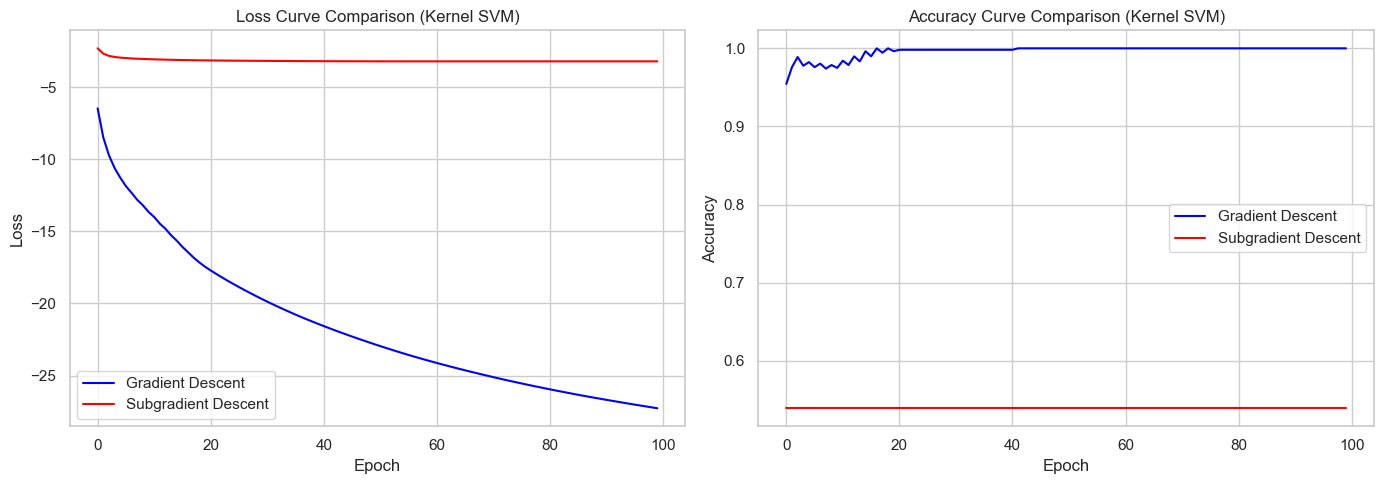

In [79]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid')


gd_losses = model.gd_losses
subgd_losses = model_Two.subgd_losses

gd_acc = model.gd_accuracies
subgd_acc = model_Two.subgd_accuracies

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(gd_losses, label='Gradient Descent', color='blue')
axes[0].plot(subgd_losses, label='Subgradient Descent', color='red')
axes[0].set_title("Loss Curve Comparison (Kernel SVM)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy Curve
axes[1].plot(gd_acc, label='Gradient Descent', color='blue')
axes[1].plot(subgd_acc, label='Subgradient Descent', color='red')
axes[1].set_title("Accuracy Curve Comparison (Kernel SVM)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [83]:
gd_train_acc = model.gd_accuracies[-1]
subgd_train_acc = model_Two.subgd_accuracies[-1]

gd_val_acc = model.gd_val_accuracies[-1] if model.gd_val_accuracies[0] is not None else None
subgd_val_acc = model_Two.subgd_val_accuracies[-1] if model_Two.subgd_val_accuracies[0] is not None else None

# Create summary table
results = pd.DataFrame({
    'Method': ['Gradient Descent', 'Subgradient Descent'],
    'Train Accuracy': [gd_train_acc, subgd_train_acc],
    'Validation Accuracy': [gd_val_acc, subgd_val_acc],
    'Loss Std Dev': [np.std(gd_losses), np.std(subgd_losses)],
    'Final Loss': [gd_losses[-1], subgd_losses[-1]]
})

results.style.background_gradient(cmap='coolwarm', axis=1)


,Method,Train Accuracy,Validation Accuracy,Loss Std Dev,Final Loss
0,Gradient Descent,1.000000,1.000000,4.896066,-27.260829
1,Subgradient Descent,0.539461,0.577778,0.120494,-3.221086
